# Cyclic Voltammetry Simulation Tutorial

This tutorial demonstrates how to simulate a **Cyclic Voltammogram (CV)** with **Butler-Volmer kinetics**, a single-electron transfer (**E mechanism**), and **1D semi-infinite planar diffusion** using the **Explicit Finite Difference (EFD)** solver in **Soft Potato 3.0**.

## 1. Environment Verification & Installation

We verify whether `softpotato` is installed in the current environment; if not, we install it automatically.

In [1]:
try:
    import softpotato as sp
    print(f"Soft Potato {sp.__version__} is already installed.")
except ImportError:
    import sys, subprocess
    print("Installing softpotato...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "softpotato"])
    import softpotato as sp
    print(f"Soft Potato {sp.__version__} installed successfully.")

Soft Potato 3.0.0rc1 is already installed.


## 2. Theory: Butler-Volmer Kinetics & Mass Transport

### 2.1 The Electrochemical Reaction
We consider a single-electron heterogeneous reduction at a planar macroelectrode:

$$\text{O} + e^- \rightleftharpoons \text{R}$$

### 2.2 Butler-Volmer Kinetics
The forward (reduction, $k_f$) and backward (oxidation, $k_b$) heterogeneous rate constants depend on overpotential $\eta = E - E^0$ according to the **Butler-Volmer equation**:

$$k_f(E) = k_0 \exp\left( -\alpha \frac{n F}{R T} (E - E^0) \right)$$

$$k_b(E) = k_0 \exp\left( (1 - \alpha) \frac{n F}{R T} (E - E^0) \right)$$

where:

* $k_0$: Standard heterogeneous rate constant (cm/s)
* $\alpha$: Transfer coefficient (typically $\approx 0.5$)
* $n$: Number of electrons transferred ($n = 1$)
* $F$: Faraday constant ($96,485\text{ C/mol}$)
* $R$: Universal gas constant ($8.314\text{ J/(mol}\cdot\text{K)}$)
* $T$: Absolute temperature ($298.15\text{ K}$)

The net molar reduction flux at the electrode surface ($x = 0$) is:

$$J(E) = k_f(E) c_{\text{O}}(0, t) - k_b(E) c_{\text{R}}(0, t)$$

And the resulting Faradaic current is:

$$i(t) = n F A J(E)$$

### 2.3 Fick's Second Law (1D Planar Diffusion)
In the solution bulk ($x > 0$), mass transport is governed by Fick's second law:

$$\frac{\partial c_{\text{O}}}{\partial t} = D_{\text{O}} \frac{\partial^2 c_{\text{O}}}{\partial x^2}, \quad \frac{\partial c_{\text{R}}}{\partial t} = D_{\text{R}} \frac{\partial^2 c_{\text{R}}}{\partial x^2}$$

## 3. Configuring the Simulation

Soft Potato enforces strict **CGS units** across all modules ($D$ in $\text{cm}^2/\text{s}$, $c$ in $\text{mol}/\text{cm}^3$, area in $\text{cm}^2$, potential in $\text{V}$).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import softpotato as sp
from softpotato.analytical import randles_sevcik

# 1. Define chemical species (1 mM = 1e-6 mol/cm^3)
spec_O = sp.core.Species(name="O", D=1e-5, c_bulk=1e-6)
spec_R = sp.core.Species(name="R", D=1e-5, c_bulk=0.0)

# 2. Define Butler-Volmer kinetics and reaction mechanism
# k0 = 1e-2 cm/s (quasi-reversible electron transfer), alpha = 0.5
bv = sp.kinetics.ButlerVolmer(k0=1e-2, alpha=0.5)
rxn = sp.core.ElectrochemicalReaction(
    reactants=[spec_O], products=[spec_R], n_electrons=1, E0=0.0, kinetics=bv
)
mechanism = sp.core.Mechanism([rxn])
print(mechanism)

Mechanism:
  Species: Species O (D=1.00e-05 cm²/s, c_bulk=1.00e-06 mol/cm³, z=0), Species R (D=1.00e-05 cm²/s, c_bulk=0.00e+00 mol/cm³, z=0)
  Electrochemical Reactions:
  O + e⁻ ⇌ R (E0 = 0.000 V)
  Chemical Reactions:
  None


## 4. Setting Up Geometry, Technique & Solver

In [3]:
# 3. Spatial grid & electrode geometry
grid = sp.geometry.UniformGrid(x_max=0.08, nodes=500)
electrode = sp.geometry.PlanarElectrode(area=0.0707, grid=grid)

# 4. Excitation technique: Cyclic Voltammetry
# Scan from 0.4 V to -0.4 V and back to 0.4 V at 0.1 V/s
cv = sp.techniques.CyclicVoltammetry(
    E_initial=0.4,
    E_vertex1=-0.4,
    scan_rate=0.1,
    n_sweeps=2,
    dE=0.002,
)

# 5. Numerical PDE solver
solver = sp.simulate.Solver(mechanism, electrode, cv, method="EFD", auto_substep=True)
print(f"Ready to simulate {len(cv.potential)} potential steps over {cv.duration:.2f} seconds.")

Ready to simulate 801 potential steps over 16.00 seconds.


## 5. Running the Simulation & Plotting Results

/tmp/ipykernel_16196/1588767584.py:2: UserWarning: CFL stability condition exceeded (lambda = 7.781 > 0.5). Automatically sub-stepping with 18 internal steps per technique point.
  result = solver.run()


Simulated Cathodic Peak Current:  -0.00 µA
Randles-Sevcik Analytical Peak:   18.99 µA


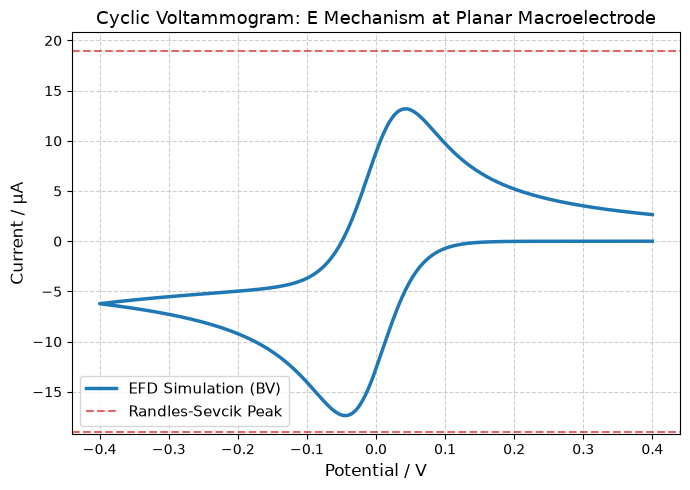

In [4]:
# Execute the simulation
result = solver.run()

# Calculate analytical peak current via Randles-Sevcik for comparison
i_p_analytical = randles_sevcik(
    n=1, area=electrode.area, D=spec_O.D, c_bulk=spec_O.c_bulk, scan_rate=cv.scan_rate
)

sweep1_len = len(cv.potential) // 2
i_p_sim = np.max(result.current[:sweep1_len])
print(f"Simulated Cathodic Peak Current:  {i_p_sim * 1e6:.2f} µA")
print(f"Randles-Sevcik Analytical Peak:   {i_p_analytical * 1e6:.2f} µA")

# Plot the voltammogram
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(result.potential, result.current * 1e6, lw=2.5, color="#1f77b4", label="EFD Simulation (BV)")
ax.axhline(i_p_analytical * 1e6, color="#d62728", linestyle="--", alpha=0.7, label="Randles-Sevcik Peak")
ax.axhline(-i_p_analytical * 1e6, color="#d62728", linestyle="--", alpha=0.7)
ax.set_xlabel("Potential / V", fontsize=12)
ax.set_ylabel("Current / µA", fontsize=12)
ax.set_title("Cyclic Voltammogram: E Mechanism at Planar Macroelectrode", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. Inspecting Spatial Concentration Profiles

We can also inspect the final concentration profiles $c_{\text{O}}(x)$ and $c_{\text{R}}(x)$ across the diffusion layer.

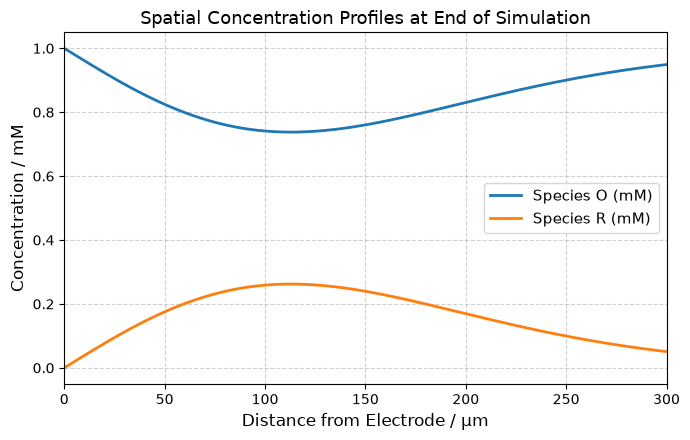

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_um = grid.x * 1e4  # Convert cm to micrometers (µm)

ax.plot(x_um, result.species_profiles["O"] * 1e6, lw=2, label="Species O (mM)", color="#1f77b4")
ax.plot(x_um, result.species_profiles["R"] * 1e6, lw=2, label="Species R (mM)", color="#ff7f0e")
ax.set_xlim(0, 300)  # Focus on the first 300 µm near the electrode
ax.set_xlabel("Distance from Electrode / µm", fontsize=12)
ax.set_ylabel("Concentration / mM", fontsize=12)
ax.set_title("Spatial Concentration Profiles at End of Simulation", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()